## Configuración inicial y autenticación con BigQuery

Se importan las librerías necesarias de Google Cloud y se establece el identificador del proyecto. También se utiliza la autenticación predeterminada de gcloud para acceder a BigQuery.

In [3]:
import sys
!{sys.executable} -m pip install google-cloud-bigquery db-dtypes google-auth

import db_dtypes

from google.cloud import bigquery

PROJECT_ID = "project3grupo1"

# Usa Application Default Credentials (gcloud auth application-default login)
client = bigquery.Client(project=PROJECT_ID)
print("✅ Conectado a BigQuery con Application Default Credentials")

datasets = list(client.list_datasets())
for ds in datasets:
    print(ds.dataset_id)


✅ Conectado a BigQuery con Application Default Credentials


c:\Users\Sergi\anaconda3\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


airbnb_features
airbnb_raw
dbt_transform


## Definición de la consulta SQL

Se define una cadena que contiene la consulta SQL para extraer todos los registros de la tabla de características de ocupación (mart_occupancy_features).

In [4]:
query = """
SELECT *
FROM `project3grupo1.dbt_transform.mart_occupancy_features`
"""

df_final = client.query(query).to_dataframe()
df_final.head()
df_final.columns

c:\Users\Sergi\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Index(['is_occupied', 'date', 'day_of_week', 'month', 'year', 'is_weekend',
       'days_to_next_holiday', 'listing_id', 'neighbourhood_cleansed',
       'room_type', 'accommodates', 'bedrooms', 'beds', 'listing_price',
       'minimum_nights', 'number_of_reviews', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'latitude', 'longitude',
       'temp_max', 'temp_min', 'temp_mean', 'precipitation_mm', 'num_events',
       'num_concerts', 'num_sports', 'num_festivals', 'max_attendance',
       'total_attendance', 'is_holiday'],
      dtype='object')

## Exploración preliminar de ocupación y características

Se importan bibliotecas y se realizan cálculos exploratorios sobre el dataframe `df_final`: distribución de `is_occupied`, ocupación media por tipo de habitación (`room_type`) y por capacidad (`accommodates`). Esto permite identificar tendencias iniciales en la ocupación.

In [5]:
import pandas as pd

df_final['is_occupied'].value_counts(normalize=True)
df_final.groupby('room_type')['is_occupied'].mean()
df_final.groupby('accommodates')['is_occupied'].mean()
df_final.groupby('bedrooms')['is_occupied'].mean()
df_final[['review_scores_rating', 'is_occupied']].corr()
df_final.groupby(pd.qcut(df_final['review_scores_rating'], 5))['is_occupied'].mean()


C:\Users\Sergi\AppData\Local\Temp\ipykernel_3036\2335005818.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby(pd.qcut(df_final['review_scores_rating'], 5))['is_occupied'].mean()


review_scores_rating
(0.999, 4.45]    0.351085
(4.45, 4.65]     0.358855
(4.65, 4.79]     0.380356
(4.79, 4.94]     0.408098
(4.94, 5.0]      0.391733
Name: is_occupied, dtype: Float64

## Análisis de correlaciones

Se importan las bibliotecas `seaborn` y `matplotlib` y se representa en un mapa de calor la matriz de correlaciones entre las variables numéricas del conjunto. Esto ayuda a identificar relaciones lineales entre variables.

<Axes: >

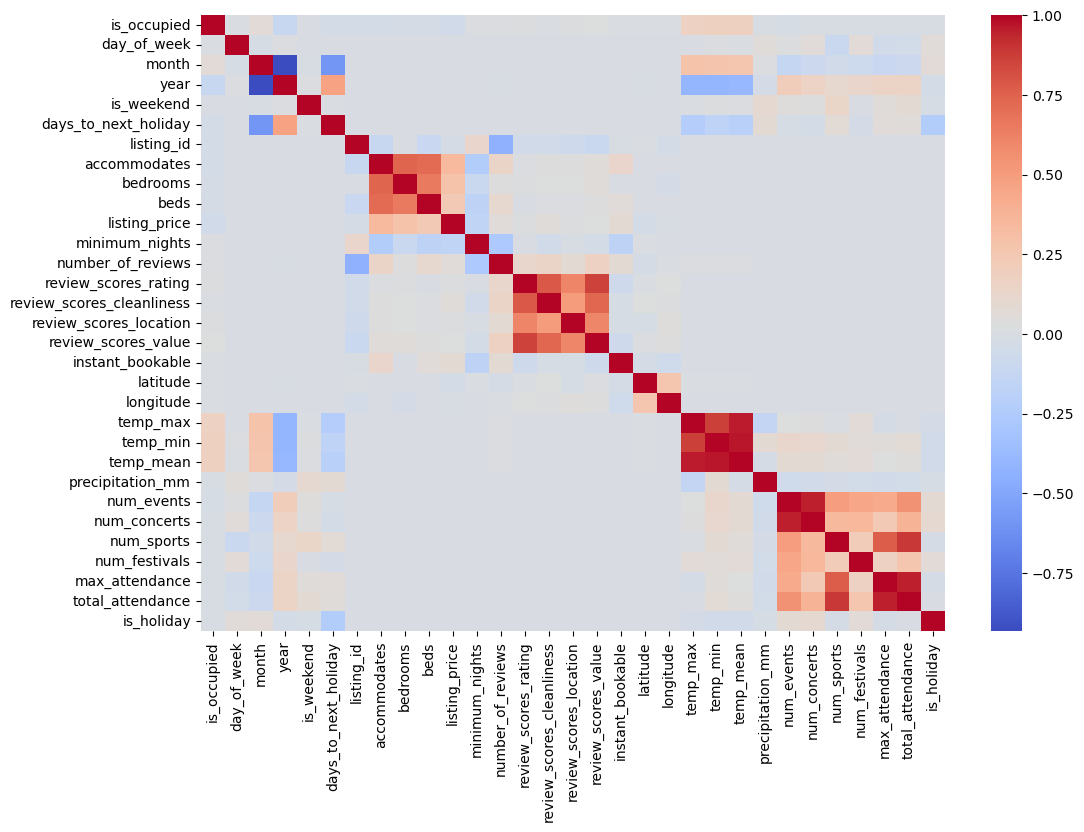

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_final.corr(numeric_only=True), cmap='coolwarm')

## Distribución y valores nulos de `is_occupied`

Se analizan los valores de la variable `is_occupied`: conteo absoluto, conteo normalizado, número de valores nulos y el tamaño total del conjunto de datos.

In [7]:
df_final["is_occupied"].value_counts()
df_final["is_occupied"].value_counts(normalize=True)

df_final["is_occupied"].isna().sum()
len(df_final)

4369397

## Distribución de `is_occupied` incluyendo valores nulos

Se examina la distribución de `is_occupied` sin eliminar valores nulos mediante `value_counts(dropna=False)`.

In [8]:
df_final["is_occupied"].value_counts(dropna=False)

is_occupied
0    2764465
1    1604932
Name: count, dtype: Int64

## Proporción de ocupación y desocupación

Se calcula la proporción de los valores de `is_occupied` con respecto al total de registros para entender el desbalance de clases.

In [9]:
df_final["is_occupied"].value_counts(normalize=True)

is_occupied
0    0.632688
1    0.367312
Name: proportion, dtype: Float64

## Registros por alojamiento (`listing_id`)

Se agrupan los datos por `is_occupied` y se cuenta el número de registros por alojamiento para comprobar la presencia de duplicados y la distribución de observaciones por `listing_id`.

In [10]:
df_final.groupby("is_occupied")["listing_id"].count()

is_occupied
0    2764465
1    1604932
Name: listing_id, dtype: Int64

## Definición de nombres de día

Se crea un diccionario que asigna cada número de día de la semana a su nombre correspondiente (lunes a domingo). Esto se utilizará para sustituir valores numéricos por nombres legibles.

In [11]:
mapping = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

df_final["day_name"] = df_final["day_of_week"].map(mapping)
df_final.groupby("day_name")["is_occupied"].mean().sort_values()
df_final.groupby("day_name")["is_occupied"].mean().reindex(order)


day_name
Monday       0.362728
Tuesday      0.365121
Wednesday    0.362282
Thursday     0.362585
Friday       0.367383
Saturday     0.375217
Sunday       0.375862
Name: is_occupied, dtype: Float64

## Ocupación media por día de la semana

Se agrupan los datos por nombre del día (`day_name`) y se calcula la ocupación media. A continuación, se grafica la ocupación media por día para analizar patrones semanales.

<Axes: xlabel='day_name'>

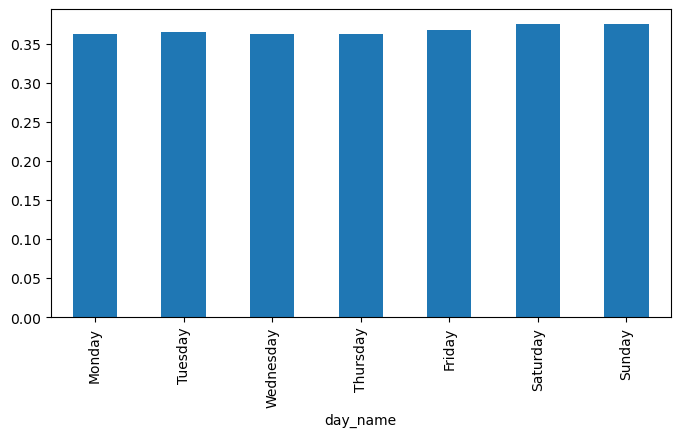

In [12]:
df_final.groupby("day_name")["is_occupied"].mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).plot(kind="bar", figsize=(8,4))

## Ocupación media por mes

Se calcula la ocupación media de `is_occupied` para cada mes y se ordena por índice para facilitar el análisis temporal.

In [13]:
df_final.groupby("month")["is_occupied"].mean()
ocupacion_mes = df_final.groupby("month")["is_occupied"].mean().sort_index()
ocupacion_mes


month
1     0.293705
2     0.293624
3     0.311882
4     0.335067
5     0.358447
6     0.752674
7     0.592217
8     0.411018
9     0.591927
10    0.511992
11    0.325668
12    0.262679
Name: is_occupied, dtype: Float64

## Visualización de la ocupación por mes

Se grafica la ocupación media por mes usando un gráfico de líneas para mostrar la estacionalidad a lo largo del año.

<Axes: xlabel='month'>

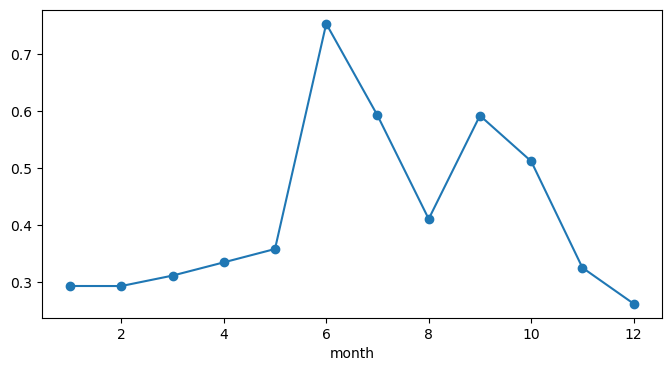

In [14]:
ocupacion_mes.plot(marker="o", figsize=(8,4))

## Análisis del mes de junio

Se evalúa el número de registros y el número de días únicos presentes en el dataset para el mes 6 (junio), con el fin de detectar posibles sesgos debidos a datos incompletos.

In [15]:
df_final[df_final["month"] == 6].shape
df_final[df_final["month"] == 6]["date"].nunique()

8

## Estadísticas agregadas por mes

Se calcula un conjunto de estadísticas para cada mes: ocupación media (`ocupacion_media`), total de registros, número de días únicos (`dias_unicos`) y porcentaje de datos (`pct_datos`). Esto permite evaluar la calidad y representatividad de los datos por mes.

In [16]:
total_rows = len(df_final)

ocupacion_mes = df_final.groupby("month").agg(
    ocupacion_media=("is_occupied", "mean"),
    total_registros=("is_occupied", "count"),
    dias_unicos=("date", "nunique")
)

ocupacion_mes["pct_datos"] = ocupacion_mes["total_registros"] / total_rows * 100

ocupacion_mes.sort_index()

,ocupacion_media,total_registros,dias_unicos,pct_datos
month,,,,
1,0.293705,509051,31,11.650372
2,0.293624,459788,28,10.522917
3,0.311882,509051,31,11.650372
4,0.335067,492630,30,11.274553
5,0.358447,279157,17,6.388914
6,0.752674,27951,8,0.639699
7,0.592217,128588,31,2.942923
8,0.411018,128588,31,2.942923
9,0.591927,323861,30,7.41203


## Filtrado de meses representativos

Se seleccionan los meses que tienen un porcentaje de datos superior al umbral establecido (>5%) para centrarse únicamente en periodos con suficientes observaciones.

In [22]:
meses_validos = ocupacion_mes[ocupacion_mes["pct_datos"] > 0].index

df_filtrado = df_final[df_final["month"].isin(meses_validos)]


## Clasificación de meses en estaciones del año

Se define una función que asigna cada mes a su estación (invierno, primavera, verano u otoño) y se aplica al conjunto de datos filtrado para realizar análisis estacional.

In [23]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df_filtrado["season"] = df_filtrado["month"].apply(get_season)

## Ocupación media por estación

Se calculan y se ordenan las ocupaciones medias por estación del año para identificar la temporada con mayor y menor demanda.

In [24]:
df_filtrado.groupby("season")["is_occupied"].mean().sort_values()

season
Winter    0.282993
Spring    0.330948
Autumn    0.462276
Summer    0.526229
Name: is_occupied, dtype: Float64

## Visualización de la ocupación por estación

Se crea un gráfico de barras que muestra la ocupación media por estación, lo que facilita la interpretación de la estacionalidad.

<Axes: xlabel='season'>

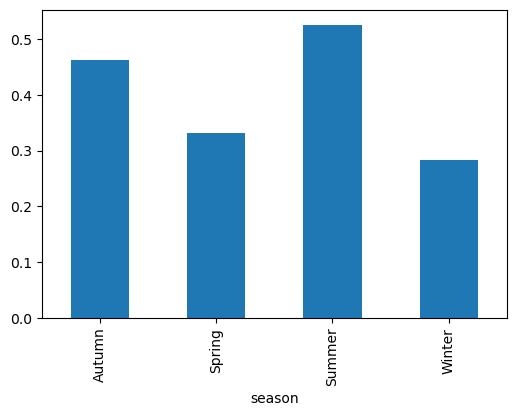

In [25]:
df_filtrado.groupby("season")["is_occupied"].mean().plot(kind="bar", figsize=(6,4))

## Agrupación del número de eventos

Se crea una variable categórica `event_level` que agrupa el número de eventos en rangos (0, 1–5, 6–10, 11–20, más de 20). Esto permite analizar el efecto de diferentes niveles de eventos en la ocupación.

In [26]:

df_filtrado["event_level"] = pd.cut(
    df_filtrado["num_events"],
    bins=[-1, 0, 5, 10, 20, 50],
    labels=["0", "1-5", "6-10", "11-20", "20+"]
)
df_filtrado.groupby("event_level")["is_occupied"].mean()

C:\Users\Sergi\AppData\Local\Temp\ipykernel_3036\2913567764.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby("event_level")["is_occupied"].mean()


event_level
0        0.370644
1-5      0.329712
6-10     0.311689
11-20    0.306817
20+      0.339078
Name: is_occupied, dtype: Float64

## Agrupación de la asistencia total a eventos

Se discretiza la variable `total_attendance` en quintiles usando `qcut` para agrupar días según la asistencia a eventos y estudiar su relación con la ocupación.

In [27]:
df_filtrado["attendance_level"] = pd.qcut(
    df_filtrado["total_attendance"],
    q=5,
    duplicates="drop"
)

df_filtrado.groupby("attendance_level")["is_occupied"].mean()

C:\Users\Sergi\AppData\Local\Temp\ipykernel_3036\1893723708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby("attendance_level")["is_occupied"].mean()


attendance_level
(-0.001, 199138.0]    0.367312
Name: is_occupied, dtype: Float64

## Distribución de asistencia total

Se muestra la frecuencia de los valores de `total_attendance` más comunes para entender la distribución de asistencia a eventos en el dataset.

In [28]:
df_filtrado["total_attendance"].value_counts().head(10)

total_attendance
0         4040977
6282        16421
20041       16421
39624       16421
6859        16421
48387       16421
1423        16421
40176       16421
20000       16421
199138      16421
Name: count, dtype: Int64

## Influencia de la presencia de eventos en la ocupación

Se crea una variable binaria `has_event` que indica si hay asistencia total mayor a 0. Se agrupan los datos según `has_event` y se calcula la ocupación media para evaluar la influencia de la presencia de eventos.

In [29]:
df_filtrado["has_event"] = (df_filtrado["total_attendance"] > 0).astype(int)
df_filtrado.groupby("has_event")["is_occupied"].mean()

has_event
0    0.370644
1     0.32632
Name: is_occupied, dtype: Float64

## Proporción de días con y sin eventos

Se calculan las proporciones de días con y sin eventos para comprender la prevalencia de cada caso en el conjunto de datos.

In [30]:
# ¿Cuántos días con evento vs sin evento?
df_filtrado["has_event"].value_counts(normalize=True)

has_event
0    0.924836
1    0.075164
Name: proportion, dtype: float64

## Distribución de eventos por mes

Se contabiliza el número de observaciones con y sin eventos por mes y se presenta en formato tabla (`unstack`) para identificar meses con mayor o menor presencia de eventos.

In [31]:
# ¿Eventos concentrados en ciertos meses?
df_filtrado.groupby(["month","has_event"])["is_occupied"].count().unstack()

has_event,0,1
month,,
1,426946,82105
2,459788,<NA>
3,509051,<NA>
4,295578,197052
5,229894,49263
6,27951,<NA>
7,128588,<NA>
8,128588,<NA>
9,323861,<NA>


## Efecto de los festivos en la ocupación

Se calcula la ocupación media según la variable `is_holiday` para explorar si los días festivos influyen en la ocupación.

In [32]:
df_filtrado.groupby("is_holiday")["is_occupied"].mean()


is_holiday
0    0.368387
1    0.343876
Name: is_occupied, dtype: Float64

## Impacto de la temperatura media

Se agrupan los datos en intervalos de temperatura media (`temp_mean`) y se calcula la ocupación media en cada rango, con el fin de detectar el efecto del clima sobre la ocupación.

In [33]:
df_filtrado.groupby(pd.cut(df_filtrado["temp_mean"], bins=10))["is_occupied"].mean()

C:\Users\Sergi\AppData\Local\Temp\ipykernel_3036\3875176168.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby(pd.cut(df_filtrado["temp_mean"], bins=10))["is_occupied"].mean()


temp_mean
(3.574, 6.25]    0.287437
(6.25, 8.9]      0.299482
(8.9, 11.55]     0.286641
(11.55, 14.2]    0.307343
(14.2, 16.85]    0.364448
(16.85, 19.5]    0.448852
(19.5, 22.15]    0.502139
(22.15, 24.8]    0.550107
(24.8, 27.45]    0.539406
(27.45, 30.1]    0.584782
Name: is_occupied, dtype: Float64

## Visualización de ocupación según temperatura

Se grafica la ocupación media por intervalos de temperatura para mostrar la tendencia observada en el análisis anterior.

C:\Users\Sergi\AppData\Local\Temp\ipykernel_3036\3877184181.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby(


<Axes: xlabel='temp_mean'>

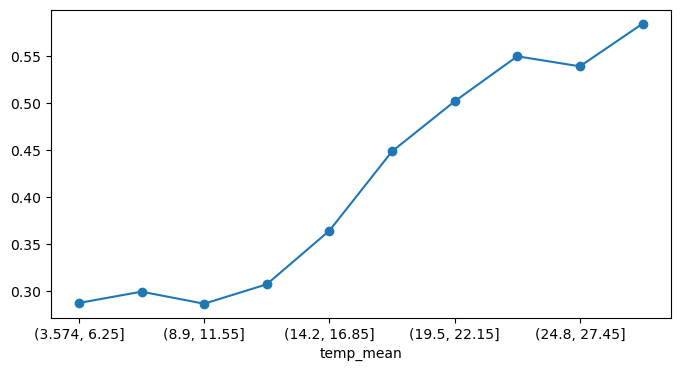

In [34]:
df_filtrado.groupby(
    pd.cut(df_filtrado["temp_mean"], bins=10)
)["is_occupied"].mean().plot(marker="o", figsize=(8,4))

## Análisis de la precipitación

Se evalúa la relación entre la precipitación (`rain_mm`) agrupada en intervalos y la ocupación media, buscando patrones asociados a días lluviosos.

In [36]:
df_filtrado.groupby(
    pd.cut(df_filtrado["rain_mm"], bins=10)
)["is_occupied"].mean()

KeyError: 'rain_mm'

## Interacción entre fin de semana y temperatura

Se calcula la ocupación media combinando la variable binaria `is_weekend` con intervalos de temperatura media. Esto permite ver cómo el efecto del fin de semana varía según el clima.

In [37]:
df_filtrado.groupby(
    ["is_weekend", pd.cut(df_filtrado["temp_mean"], bins=5)]
)["is_occupied"].mean()

C:\Users\Sergi\AppData\Local\Temp\ipykernel_3036\1619582379.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby(


is_weekend  temp_mean   
0           (3.574, 8.9]    0.297515
            (8.9, 14.2]     0.295893
            (14.2, 19.5]    0.421159
            (19.5, 24.8]    0.526278
            (24.8, 30.1]    0.554823
1           (3.574, 8.9]    0.298703
            (8.9, 14.2]     0.298868
            (14.2, 19.5]    0.403606
            (19.5, 24.8]    0.550597
            (24.8, 30.1]    0.580039
Name: is_occupied, dtype: Float64

## Ocupación según estación y fin de semana

Se calcula la ocupación media combinando la estación del año con la variable `is_weekend`, mostrando los resultados en una tabla (`unstack`).

In [38]:
df_filtrado.groupby(["season", "is_weekend"])["is_occupied"].mean().unstack()

is_weekend,0,1
season,,
Autumn,0.46223,0.462388
Spring,0.329988,0.333245
Summer,0.528019,0.521866
Winter,0.282143,0.285203


## Selección de características para el modelo

Se define una lista de variables (`features`) que se utilizarán como entradas para entrenar el modelo de clasificación de ocupación.

In [39]:
features = [
    "temp_mean",
    "is_weekend",
    "month",
    "accommodates",
    "bedrooms",
    "beds",
    "number_of_reviews"
]

X = df_filtrado[features]
y = df_filtrado["is_occupied"]

X = X.fillna(0)

## Importación de bibliotecas para modelado

Se importan las funciones de `sklearn` necesarias para dividir los datos, entrenar un modelo de Random Forest y evaluar su desempeño.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import sys

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamiento progresivo: warm_start añade árboles en cada iteración
model = RandomForestClassifier(
    n_estimators=10,  # empezamos con 10 árboles
    warm_start=True,
    random_state=42
)

step = 10        # árboles por paso
total = 100      # total de árboles

print(f"{'Árboles':>8} | {'Train Acc':>10} | {'Test Acc':>10}")
print("-" * 35)

for n in range(step, total + step, step):
    model.n_estimators = n
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))

    print(f"{n:>8} | {train_acc:>10.4f} | {test_acc:>10.4f}")
    sys.stdout.flush()

print("\n✅ Entrenamiento completado")
print(f"Train accuracy final: {train_acc:.4f}")
print(f"Test  accuracy final: {test_acc:.4f}")


 Árboles |  Train Acc |   Test Acc
-----------------------------------
      10 |     0.7952 |     0.6906
      20 |     0.7987 |     0.6927
      30 |     0.7996 |     0.6939
      40 |     0.7999 |     0.6940
      50 |     0.8001 |     0.6945
      60 |     0.8002 |     0.6945
      70 |     0.8002 |     0.6945
      80 |     0.8002 |     0.6946
      90 |     0.8002 |     0.6948
     100 |     0.8002 |     0.6951

✅ Entrenamiento completado
Train accuracy final: 0.8002
Test  accuracy final: 0.6951
